In [144]:
# CELL 1: IMPORTING LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u
from astropy.constants import G

# Just to make sure plots appear in the notebook
%matplotlib inline

In [145]:
# CELL 2: PHYSICAL CONSTANTS 
M_mars = 6.4171e23 * u.kg 
R_mars = 3389.5 * u.km

# Standard Mars Gravity
g_mars = -(G * M_mars / R_mars**2)
g_mars_val = g_mars.to(u.m / u.s**2).value 

# Robotic Lander Properties (these values are  on literature)
rho_0 = 0.0158         # kg/m^3
H_scale = 11100        # meters
mass = 2000.0          # kg 
area = 16.0            # m^2
Cd = 1.2               # drag coefficient
max_thrust = 35000.0   # Newtons 

In [146]:
# CELL 3: SIMULATION LOOP
#Initial conditions below
altitude = 15000.0     
velocity = -500.0      
t = 0.0
dt = 0.1            

history = {'t': [], 'alt': [], 'vel': [], 'thrust': []}

while altitude > 0:
    # 1. Physics: Drag
    rho = rho_0 * np.exp(-altitude / H_scale)
    drag = 0.5 * rho * (velocity**2) * Cd * area
    if velocity < 0: drag = -drag
    
    # 2. GNC Logic
    if altitude < 5000:
        target_v = -2.0 
        weight_force = mass * -g_mars_val
        # Proportional gain tuned for the 2000kg mass
        thrust_req = (weight_force - drag) + (target_v - velocity) * 5000.0
        thrust = np.clip(thrust_req, 0, max_thrust)
    else:
        # Coasting phase!
        thrust = 0.0
    
    # 3. Newton's Second Law
    acceleration = ((mass * g_mars_val) + thrust - drag) / mass
    
    # 4. Euler Integration
    velocity += acceleration * dt
    altitude += velocity * dt
    t += dt
    
    # 5. Saving data
    history['t'].append(t)
    history['alt'].append(altitude)
    history['vel'].append(velocity)
    history['thrust'].append(thrust)

# Output Success/Failure
final_speed = abs(velocity)
print(f"STATUS: {'SUCCESS' if final_speed <= 2.1 else 'FAILURE'}")
print(f"Touchdown Velocity: {final_speed:.2f} m/s")

STATUS: SUCCESS
Touchdown Velocity: 2.00 m/s


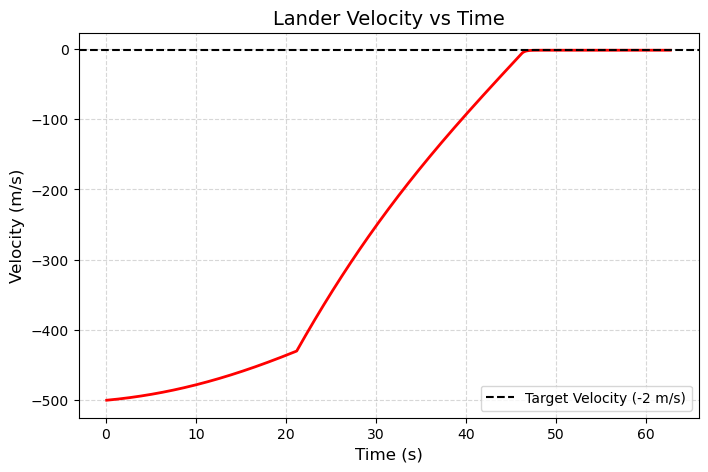

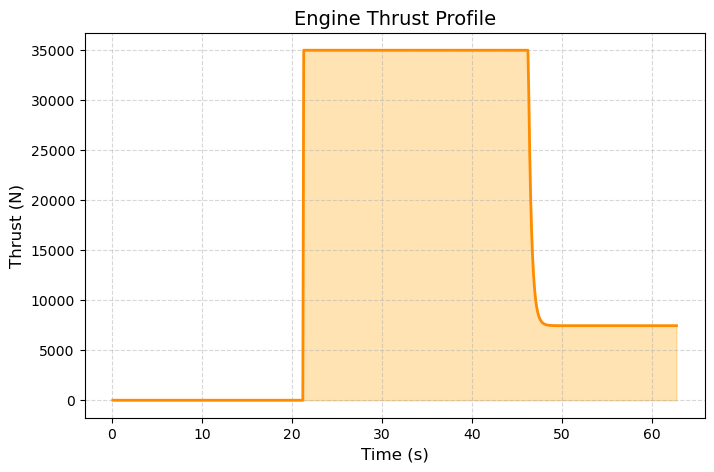

In [153]:
# CELL 4: PLOTS
# GRAPH 1: VELOCITY
plt.figure(figsize=(8, 5))
plt.plot(history['t'], history['vel'], color='red', lw=2)
plt.axhline(y=-2, color='black', linestyle='--', label='Target Velocity (-2 m/s)')
plt.title("Lander Velocity vs Time", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Velocity (m/s)", fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.savefig("velocity_report.png", dpi=300)
plt.show()

# GRAPH 2: THRUST
plt.figure(figsize=(8, 5))
plt.fill_between(history['t'], history['thrust'], color='orange', alpha=0.3)
# Darker line on top for clarity
plt.plot(history['t'], history['thrust'], color='darkorange', lw=2)
plt.title("Engine Thrust Profile", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Thrust (N)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.savefig("thrust_report.png", dpi=300)
plt.show()

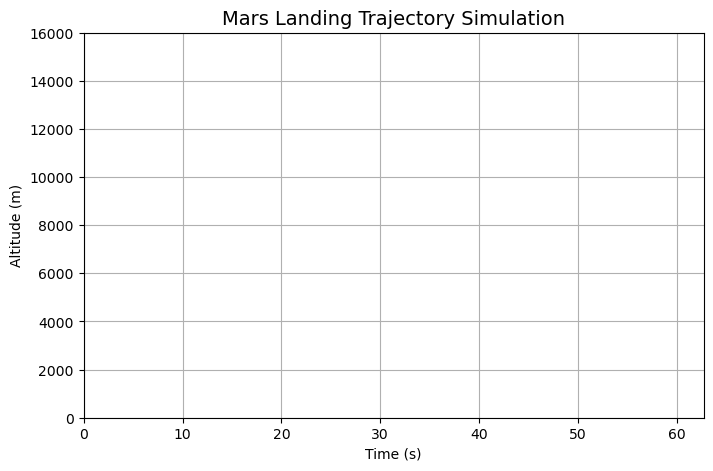

In [156]:
# CELL 5: ANIMATION
from matplotlib.animation import FuncAnimation

# 1. Setup of figure
fig_ani, ax_ani = plt.subplots(figsize=(8, 5))
ax_ani.set_xlim(0, max(history['t']))
ax_ani.set_ylim(0, 16000)
ax_ani.set_title("Mars Landing Trajectory Simulation", fontsize=14)
ax_ani.set_xlabel("Time (s)")
ax_ani.set_ylabel("Altitude (m)")
ax_ani.grid(True)

line, = ax_ani.plot([], [], color='blue', lw=2)

def init():
    line.set_data([], [])
    return line,

def update(frame):
    line.set_data(history['t'][:frame], history['alt'][:frame])
    return line,

# 2. Creating the animation
ani = FuncAnimation(fig_ani, update, frames=range(0, len(history['t']), 10), 
                    init_func=init, blit=True, interval=50, repeat=False)

# 3. Just checking it out here u can ignore this!
plt.show() 

# 4. Saving animation 
ani.save('lander_animation.gif', writer='pillow', fps=20)
